In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
plt.style.use('seaborn-v0_8-whitegrid')

from src.testcases.gaussian import exact_solution_periodic

In [2]:
def get_data(path: str):
    data = np.load(path, allow_pickle=True)

    meta = data["meta"].item()
    config = meta["config"]
    #print(config)

    qtm_traj = data["quantum_traj"].item()
    qtm_F = qtm_traj["F"]
    qtm_rho = qtm_traj["rho"]
    qtm_u = qtm_traj["u"]

    cls_traj = data["classical_traj"].item()
    cls_F = cls_traj["F"]
    cls_rho = cls_traj["rho"]
    cls_u = cls_traj["u"]

    return config, qtm_rho, qtm_u, cls_rho, cls_u

In [3]:
path_list = ["lbm_gaussian_20251126_165028.npz", "lbm_gaussian_20251126_171021.npz", "lbm_gaussian_20251126_174932.npz"]

config_dict = {}
qtm_rho_dict = {}
qtm_u_dict = {}
cls_rho_dict = {}
cls_u_dict = {}

for path in path_list:
    config, qtm_rho, qtm_u, cls_rho, cls_u = get_data(path)
    config_dict[config['sigma0']] = config
    qtm_rho_dict[config['sigma0']] = qtm_rho
    qtm_u_dict[config['sigma0']] = qtm_u
    cls_rho_dict[config['sigma0']] = cls_rho
    cls_u_dict[config['sigma0']] = cls_u

In [4]:
def compute_errors(sigma0):
    config = config_dict[sigma0]
    qtm_rho = qtm_rho_dict[sigma0]
    qtm_u = qtm_u_dict[sigma0]
    cls_rho = cls_rho_dict[sigma0]
    cls_u = cls_u_dict[sigma0]

    ## Exact solution
    n_frames = qtm_rho.shape[0]
    exact_rho_t = exact_solution_periodic(C0=config["C0"], sigma0=config["sigma0"], x0=config["x0"],u_adv=config["u0"])
    exact_rho = np.array([exact_rho_t(t) for t in 20*np.arange(n_frames)])

    ## Density (Scalar) error
    qtm_rho_er = abs(qtm_rho - exact_rho)
    qtm_rho_rel = np.sum(qtm_rho_er, axis=(1, 2)) / np.sum(exact_rho, axis=(1, 2))

    cls_rho_er = abs(cls_rho - exact_rho)
    cls_rho_rel = np.sum(cls_rho_er, axis=(1, 2)) / np.sum(exact_rho, axis=(1, 2))

    return qtm_rho_rel, cls_rho_rel

In [5]:
qtm_rho_rel_dict = {}
cls_rho_rel_dict = {}

for sigma0 in config_dict.keys():
    qtm_rho_rel_dict[sigma0], cls_rho_rel_dict[sigma0] = compute_errors(sigma0)

In [6]:
T = 10001
H,V = config["grid_size"]
assert H == V
L = H

u_adv = config["u_adv"]

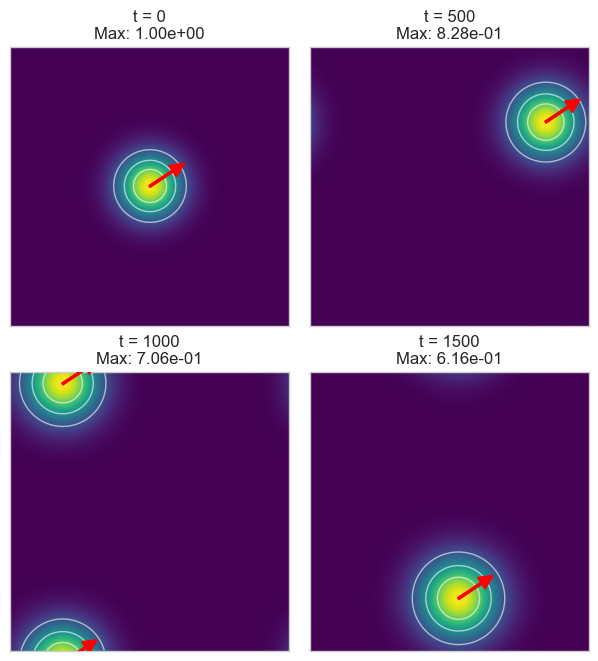

In [11]:
# Settings
indices = [0, 25, 50, 75]
## Horizontal layout
#fig, axes = plt.subplots(1, 4, figsize=(16, 4.5), sharey=True, constrained_layout=True)
## 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(6, 6.5), sharey=True, constrained_layout=True)
axes = axes.flatten()

# Vector Scaling
# We fix the visual length of the arrow to 15% of the domain size
visual_length = L * 0.15
u_norm = u_adv / np.linalg.norm(u_adv)
vec_dx = u_norm[0] * visual_length
vec_dy = u_norm[1] * visual_length

for ax, t_idx in zip(axes, indices):
    data = qtm_rho_dict[20][t_idx]

    # Local intensity limits
    local_min = data.min()
    local_max = data.max()
    local_range = local_max - local_min

    # A. Plot Field
    im = ax.imshow(data, origin='lower', extent=[0, L, 0, L],
                   vmin=local_min, vmax=local_max, cmap='viridis')

    # B. Plot Periodic Contours
    data_padded = np.pad(data, ((0, 1), (0, 1)), mode='wrap')
    xp = np.arange(L + 1) + 0.5
    yp = np.arange(L + 1) + 0.5
    levels = local_min + local_range * np.array([0.25, 0.50, 0.75])
    ax.contour(xp, yp, data_padded, levels=levels, colors='white',
               linewidths=1, alpha=0.6)

    # C. Plot Periodic Vectors
    # Find the peak center
    cy_idx, cx_idx = np.unravel_index(np.argmax(data), data.shape)

    # We plot the arrow at the center AND at all 8 periodic neighbor positions.
    # The plot limits (0, L) will clip them, creating the appearance of wrapping.
    for i in [-1, 0, 1]:
        for j in [-1, 0, 1]:
            # Shift the start position by L
            start_x = cx_idx + i * L
            start_y = cy_idx + j * L

            # Optimization: Only plot if the arrow could possibly be visible
            # (Check if start or end of arrow is within a slightly padded frame)
            end_x = start_x + vec_dx
            end_y = start_y + vec_dy

            if ((-20 < start_x < L+20) or (-20 < end_x < L+20)) and \
               ((-20 < start_y < L+20) or (-20 < end_y < L+20)):

                ax.arrow(start_x, start_y, vec_dx, vec_dy,
                         color='red',
                         width=L*0.008,
                         head_width=L*0.05,
                         head_length=L*0.05,
                         length_includes_head=True,
                         zorder=10)

    # D. Formatting
    ax.set_xlim(0, L)
    ax.set_ylim(0, L)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(direction='in', color='white')
    ax.grid(False)
    ax.set_title(f"t = {20*t_idx}\nMax: {local_max:.2e}", fontsize=12)

# Colorbar
# cbar = fig.colorbar(im, orientation='vertical', fraction=0.05, pad=0.04)
# cbar.set_label('Relative Density')
# cbar.set_ticks([])

plt.savefig("gaussian_field.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [63]:
C0, sigma0, D = config["C0"], config["sigma0"], config["D"]
n_frames = qtm_rho.shape[0]

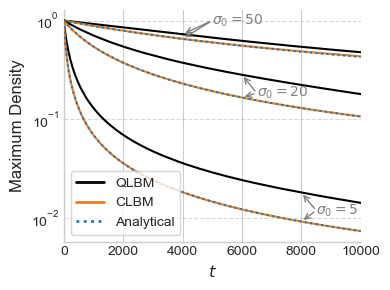

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker

n_frames = 501
frames = np.arange(n_frames)
time_steps = frames * 20

# --- 2. PLOTTING SETUP ---
fig, ax = plt.subplots(figsize=(4, 3))

# Colors
c_qtm = 'black'
c_cls = '#E67E22' # Dark Orange
c_ext = '#1f77b4' # Muted Blue
c_vec = 'gray'    # Color for the vectors (arrows)

# --- 3. USER CONFIGURATION FOR ANNOTATIONS ---
# > Adjust 'text_x' and 'text_y' here to move the labels into the white space.
# > 'target_t' is fixed based on your request.
annotation_config = {
    50: {
        "target_t": 4000,
        "text_x": 5000,     # X position of the text
        "text_y": 1.,      # Y position of the text (in data coordinates)
        "ha": "left"        # Horizontal alignment of text
    },
    20: {
        "target_t": 6000,
        "text_x": 6500,
        "text_y": 0.185,
        "ha": "left"
    },
    5: {
        "target_t": 8000,
        "text_x": 8500,
        "text_y": 0.012,
        "ha": "left"
    }
}

# --- 4. Main Plotting Loop ---
# Sort sigmas to ensure consistent layering
sorted_sigmas = sorted(config_dict.keys(), reverse=True) # [50, 20, 5]

for i, sigma0 in enumerate(sorted_sigmas):
    # Retrieve Config & Data
    config = config_dict[sigma0]
    C0 = config["C0"]
    D = config["D"]

    qtm_rho = qtm_rho_dict[sigma0]
    cls_rho = cls_rho_dict[sigma0]

    max_qtm = np.max(qtm_rho[:n_frames], axis=(1, 2))
    max_cls = np.max(cls_rho[:n_frames], axis=(1, 2))

    # Analytical Solution (Exact)
    C_t = C0 * (sigma0**2) / (sigma0**2 + 2 * D * time_steps)

    # Plot Curves
    # We use label='_nolegend_' to keep the legend clean
    ax.semilogy(time_steps, max_qtm, color=c_qtm, linewidth=1.5,
                linestyle='-', zorder=3, label='_nolegend_')
    ax.semilogy(time_steps, max_cls, color=c_cls, linewidth=1.5,
                linestyle='-', zorder=3, label='_nolegend_')
    ax.semilogy(time_steps, C_t, color=c_ext, linewidth=1.5,
                linestyle=':', zorder=3, label='_nolegend_')

    # --- 5. Draw Vectors & Text ---
    if sigma0 in annotation_config:
        settings = annotation_config[sigma0]

        # A. Find the index corresponding to the target time
        t_target = settings["target_t"]
        # Find index in time_steps closest to t_target
        idx = (np.abs(time_steps - t_target)).argmin()

        # B. Coordinates for the arrow tips (on the curves)
        tip_x = time_steps[idx]
        tip_y_qtm = max_qtm[idx]
        tip_y_cls = max_cls[idx]

        # C. Coordinates for the Text (from config)
        text_x = settings["text_x"]
        text_y = settings["text_y"]

        # D. Place the Text
        ax.text(text_x, text_y, r'$\sigma_0={}$'.format(sigma0),
                fontsize=10, color='gray',
                ha=settings['ha'], va='center')

        # E. Draw Two Arrows (Text -> QLBM) and (Text -> CLBM)
        # Use simple straight arrows (arrowstyle='->')
        common_arrow_args = dict(
            xycoords='data', textcoords='data',
            arrowprops=dict(arrowstyle='->', color=c_vec, lw=1.0)
        )

        # Vector to QLBM (Black curve)
        ax.annotate("", xy=(tip_x, tip_y_qtm), xytext=(text_x, text_y), **common_arrow_args)

        # Vector to CLBM (Orange curve)
        ax.annotate("", xy=(tip_x, tip_y_cls), xytext=(text_x, text_y), **common_arrow_args)


# --- 6. Formatting ---

# Custom Legend
legend_elements = [
    Line2D([0], [0], color=c_qtm, lw=2, linestyle='-', label='QLBM'),
    Line2D([0], [0], color=c_cls, lw=2, linestyle='-', label='CLBM'),
    Line2D([0], [0], color=c_ext, lw=2, linestyle=':', label='Analytical')
]
ax.legend(handles=legend_elements, frameon=True, fontsize=10, loc='lower left')

# Labels
ax.set_xlabel(r'$t$', fontsize=12)
ax.set_ylabel(r'Maximum Density', fontsize=12)

# Spines (Tufte style)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#ax.spines['left'].set_position(('outward', 5))
#ax.spines['bottom'].set_position(('outward', 5))

# Ticks & Limits
ax.set_xlim(0, 10000) # Extended slightly to fit 8000+ text
# Force log minor ticks
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs='auto', numticks=10))
ax.tick_params(direction='out', which='both', labelsize=10)



# Grid
plt.grid(True, which='major', axis='y', linestyle='--', alpha=0.3, color='gray')

plt.tight_layout()
plt.savefig("gaussian_decay.pdf", format="pdf", bbox_inches="tight")
plt.show()

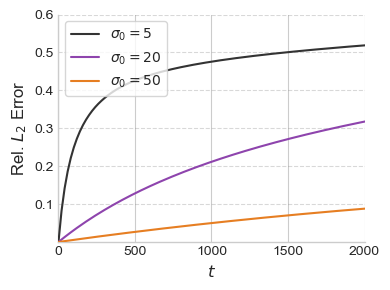

In [13]:
n_frames = 501
frames = np.arange(n_frames)
time_steps = frames * 20

# --- 2. PLOTTING SETUP ---
fig, ax = plt.subplots(figsize=(4, 3))


# --- 4. Main Plotting Loop ---
# Sort sigmas to ensure consistent layering
sorted_sigmas = sorted(config_dict.keys()) # [5,20,50]
colors = ['#333333', '#8E44AD', '#E67E22']

for i, sigma0 in enumerate(sorted_sigmas):
    # Retrieve Config & Data
    config = config_dict[sigma0]
    C0 = config["C0"]
    D = config["D"]

    qtm_rho_rel = qtm_rho_rel_dict[sigma0]
    cls_rho_rel = cls_rho_rel_dict[sigma0]


    # Plot Error Curves
    ax.plot(time_steps, qtm_rho_rel, linewidth=1.5, color=colors[i],
                linestyle='-', zorder=3, label='$\sigma_0 = {}$'.format(sigma0))


# ---  Formatting ---

# Custom Legend
ax.legend(frameon=True, fontsize=10, loc='upper left')

# Labels
ax.set_xlabel(r'$t$', fontsize=12)
ax.set_ylabel('Rel. $L_2$ Error', fontsize=12)

# Spines (Tufte style)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Ticks & Limits
ax.set_xlim(0, 2001) # Extended slightly to fit 8000+ text
ax.set_ylim(0.001, 0.6)
ax.set_xticks([0,500,1000,1500,2000])
ax.tick_params(axis='both', labelsize=10)

# Grid
plt.grid(True, which='major', axis='y', linestyle='--', alpha=0.3, color='gray')

plt.tight_layout()
plt.savefig("gaussian_error.pdf", format="pdf", bbox_inches="tight")
plt.show()